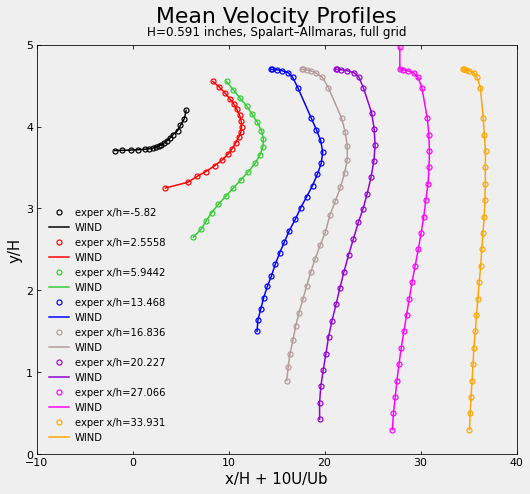

In [8]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CHANGE THIS TO YOUR FOLDER
# ============================================================
DATA_DIR = Path(r"C:\Users\20222066\OneDrive - TU Eindhoven\Documents\Desktop\CFD\exp_data\case8_2")

# Files/stations to include in the NASA-style plot
stations_to_plot = [-6, 3, 6, 14, 17, 20, 27, 34]

# Exact x/H positions used in the NASA-style figure
station_map = {
    -6: -5.82,
     3:  2.5558,
     6:  5.9442,
    14: 13.468,
    17: 16.836,
    20: 20.227,
    27: 27.066,
    34: 33.931,
}

# Colors chosen to resemble the NASA plot
colors = {
    -6: "black",
     3: "red",
     6: "limegreen",
    14: "blue",
    17: "#b59b9b",
    20: "darkviolet",
    27: "magenta",
    34: "orange",
}

OFFSET_SCALE = 10.0  # x/H + 10U/Ub


# ============================================================
# HELPERS
# ============================================================
def parse_station(path: Path) -> int:
    """
    Extract the raw station integer from filenames like:
    m__U%.x03  -> 3
    m__U%.x14  -> 14
    m__U%.x-6  -> -6
    """
    m = re.search(r"\.x(-?\d+)$", path.name)
    if not m:
        raise ValueError(f"Could not parse station from filename: {path.name}")
    return int(m.group(1))


def load_profile(path: Path):
    """
    Load one profile file.

    Assumes:
      column 0 = y/H
      column 1 = U/Ub

    If your plot looks wrong, swap the two columns below.
    """
    data = np.loadtxt(path)

    if data.ndim != 2 or data.shape[1] < 2:
        raise ValueError(f"File does not appear to have 2 columns: {path}")

    y_over_h = data[:, 0]
    u_over_ub = data[:, 1]

    return y_over_h, u_over_ub


# ============================================================
# FIND FILES
# ============================================================
all_files = list(DATA_DIR.glob("m__U%.x*"))

files = []
for f in all_files:
    s = parse_station(f)
    if s in stations_to_plot:
        files.append(f)

files = sorted(files, key=parse_station)

if not files:
    raise FileNotFoundError(
        f"No matching files found in {DATA_DIR}\n"
        f"Expected files like m__U%.x03, m__U%.x14, etc."
    )


# ============================================================
# PLOT STYLE
# ============================================================
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 22,
    "axes.labelsize": 15,
    "legend.fontsize": 10,
})

fig, ax = plt.subplots(figsize=(7.5, 7))

# light gray background similar to the screenshot
fig.patch.set_facecolor("#efefef")
ax.set_facecolor("#efefef")


# ============================================================
# PLOT DATA
# ============================================================
legend_handles = []
legend_labels = []

for f in files:
    raw_station = parse_station(f)
    x_over_h = station_map[raw_station]
    color = colors[raw_station]

    y_over_h, u_over_ub = load_profile(f)

    # NASA-style x axis:
    # x_plot = x/H + 10 * U/Ub
    x_plot = x_over_h + OFFSET_SCALE * u_over_ub

    # solid line
    line, = ax.plot(
        x_plot,
        y_over_h,
        color=color,
        linewidth=1.5
    )

    # open-circle markers
    pts, = ax.plot(
        x_plot,
        y_over_h,
        linestyle="None",
        marker="o",
        markersize=5,
        markerfacecolor="none",
        markeredgecolor=color,
        markeredgewidth=1.2
    )

    # legend in 2-line NASA-like style
    legend_handles.append(pts)
    legend_labels.append(f"exper x/h={x_over_h:g}")
    legend_handles.append(line)
    legend_labels.append("WIND")


# ============================================================
# AXES, LABELS, TITLES
# ============================================================
ax.set_xlim(-10, 40)
ax.set_ylim(0, 5)

ax.set_xlabel("x/H + 10U/Ub")
ax.set_ylabel("y/H")

ax.set_title("Mean Velocity Profiles", pad=22)
ax.text(
    0.5,
    1.015,
    "H=0.591 inches, Spalart–Allmaras, full grid",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=12
)

ax.set_xticks([-10, 0, 10, 20, 30, 40])
ax.set_yticks([0, 1, 2, 3, 4, 5])

ax.grid(False)
ax.tick_params(direction="in", top=True)


# ============================================================
# LEGEND
# ============================================================
ax.legend(
    legend_handles,
    legend_labels,
    loc="lower left",
    frameon=False,
    handlelength=2.0,
    handletextpad=0.6,
    borderaxespad=0.8,
    fontsize=10
)

plt.tight_layout()
plt.show()